# PyTorch

## Instalación de dependencias

In [18]:
%%capture
uv pip install torch torchvision numpy matplotlib scikit-learn seaborn

## Importar librerías

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

## Importar imágenes 

In [20]:
from get_images import get_images

In [21]:
# MNIST path
mnist_path = '../data/mnist'
x_train_num, y_train_num, x_test_num, y_test_num = get_images(mnist_path)

x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)
y_train = y_train_num[:50000].reshape(50000, 1)

x_val = x_train_num[50000:].reshape(10000, -1).astype(np.float32)
y_val = y_train_num[50000:].reshape(10000, 1)

x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test_num.copy().reshape(10000, 1)

## Normalizar imágenes

$$x_n= (x - μ) / σ$$

Donde:
- $μ$ = media de todo el training set
- $σ$ = desviación estándar del training set

In [22]:
def normalise(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

In [23]:
x_mean = x_train.mean()
x_std = x_train.std()

x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

In [24]:
x_train.mean(), x_train.std()

(np.float32(9.0680805e-09), np.float32(1.0))

## Mostrar imágenes 

In [25]:
x_test.shape

(10000, 784)

In [26]:
y_train.shape

(50000, 1)

In [27]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

La imagen muestreada representa un: 0


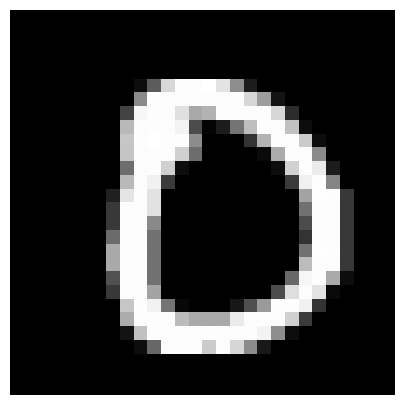

In [28]:
rnd_idx = np.random.randint(len(y_test))
print(f'La imagen muestreada representa un: {y_test[rnd_idx, 0]}')
plot_number(x_test_num[rnd_idx])

## PyTorch

## Convertir Numpy array a PyTorch (Tensores)

Un **tensor** es como un arreglo multidimensional de números. Es la forma en que PyTorch almacenan y procesa datos.

In [29]:
x_train_tensor = torch.tensor(x_train.copy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.copy(), dtype=torch.long).squeeze()

x_val_tensor = torch.tensor(x_val.copy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.copy(), dtype=torch.long).squeeze()

x_test_tensor = torch.tensor(x_test.copy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.copy(), dtype=torch.long).squeeze()

## Usar GPU de estar disponible

In [30]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
print(f'Dispositivo seleccionado: {device}')

GPU disponible: NVIDIA RTX A2000 Laptop GPU
Dispositivo seleccionado: cuda


In [31]:
print(f'Train: {x_train_tensor.shape}, {y_train_tensor.shape}')
print(f'Val: {x_val_tensor.shape}, {y_val_tensor.shape}')
print(f'Test: {x_test_tensor.shape}, {y_test_tensor.shape}')

Train: torch.Size([50000, 784]), torch.Size([50000])
Val: torch.Size([10000, 784]), torch.Size([10000])
Test: torch.Size([10000, 784]), torch.Size([10000])


## Crear DataLoaders de PyTorch

Un **DataLoader** es como un "repartidor de datos" que entrega tus datos en pequeños lotes (batches) durante el entrenamiento.

In [32]:
# Crear datasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# Configuración de batch size
batch_size = 512

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Batches de entrenamiento: {len(train_loader)}')
print(f'Batches de validación: {len(val_loader)}')
print(f'Batches de test: {len(test_loader)}')

Batches de entrenamiento: 98
Batches de validación: 20
Batches de test: 20


## Función de evaluación

In [33]:
def evaluate(model, data_loader, device):
    """
    Evalúa el modelo en un DataLoader y retorna accuracy y loss promedio
    """
    correct = 0
    total = 0
    total_loss = 0.0
    model = model.to(device=device)
    
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
        
            outputs = model(x_batch)
            loss = F.cross_entropy(outputs, y_batch)
            total_loss += loss.item()
            
            _, predicted = outputs.max(dim=1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    
    accuracy = correct / total
    avg_loss = total_loss / len(data_loader)
    return accuracy, avg_loss

## Loop de entrenamiento

In [35]:
def train_model(model, train_loader, val_loader, optimizer, device, epochs=20):
    """
    Entrena el modelo usando PyTorch DataLoaders
    """
    model = model.to(device)
    loss_hist_val = [] 
    loss_hist_train = [] 
    acc_hist_val = [] 
    acc_hist_train = [] 

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for _, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Forward pass
            outputs = model(x_batch)
            loss = F.cross_entropy(outputs, y_batch)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Evaluar en validación
        val_acc, val_loss = evaluate(model, val_loader, device)
        train_acc, train_loss = evaluate(model, train_loader, device)
        loss_hist_val.append(val_loss)
        loss_hist_train.append(train_loss)
        acc_hist_val.append(val_acc)
        acc_hist_train.append(train_acc)

        print(f'Epoch {epoch+1}/{epochs} - '
              f'Train Loss: {train_loss:.4f} - '
              f'Val Loss: {val_loss:.4f} - '
              f'Train Acc: {train_acc:.4f} ({train_acc*100:.2f}%) - '
              f'Val Acc: {val_acc:.4f} ({val_acc*100:.2f}%)')
    
    return model, loss_hist_train, loss_hist_val, acc_hist_train, acc_hist_val

## Definir y entrenar el modelo

### Busqueda LR en $[0.01, 1]$

Prueba 1: Exponente (j) = -1.3299 | Learning Rate (lr) = 0.0468
Epoch 1/30 - Train Loss: 0.5113 - Val Loss: 0.4717 - Train Acc: 0.8674 (86.74%) - Val Acc: 0.8829 (88.29%)
Epoch 2/30 - Train Loss: 0.3544 - Val Loss: 0.3248 - Train Acc: 0.8993 (89.93%) - Val Acc: 0.9098 (90.98%)
Epoch 3/30 - Train Loss: 0.3047 - Val Loss: 0.2815 - Train Acc: 0.9112 (91.12%) - Val Acc: 0.9188 (91.88%)
Epoch 4/30 - Train Loss: 0.2755 - Val Loss: 0.2575 - Train Acc: 0.9188 (91.88%) - Val Acc: 0.9232 (92.32%)
Epoch 5/30 - Train Loss: 0.2517 - Val Loss: 0.2361 - Train Acc: 0.9265 (92.65%) - Val Acc: 0.9300 (93.00%)
Epoch 6/30 - Train Loss: 0.2314 - Val Loss: 0.2180 - Train Acc: 0.9333 (93.33%) - Val Acc: 0.9365 (93.65%)
Epoch 7/30 - Train Loss: 0.2168 - Val Loss: 0.2074 - Train Acc: 0.9372 (93.72%) - Val Acc: 0.9389 (93.89%)
Epoch 8/30 - Train Loss: 0.1988 - Val Loss: 0.1913 - Train Acc: 0.9421 (94.21%) - Val Acc: 0.9468 (94.68%)
Epoch 9/30 - Train Loss: 0.1848 - Val Loss: 0.1790 - Train Acc: 0.9474 (94.74%) 

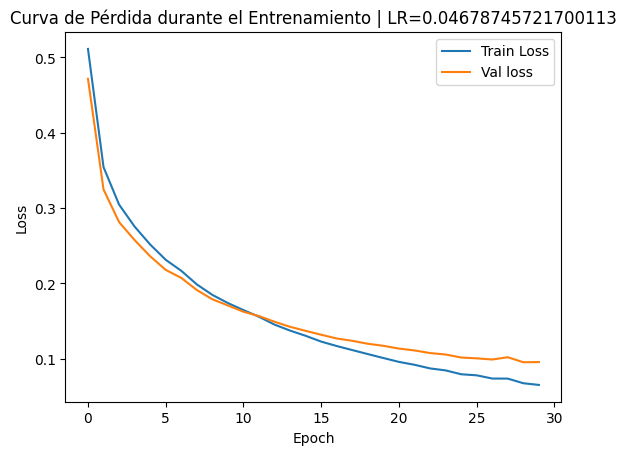

0.9711
Prueba 2: Exponente (j) = -1.0950 | Learning Rate (lr) = 0.0804
Epoch 1/30 - Train Loss: 0.4203 - Val Loss: 0.3912 - Train Acc: 0.8723 (87.23%) - Val Acc: 0.8838 (88.38%)
Epoch 2/30 - Train Loss: 0.2862 - Val Loss: 0.2663 - Train Acc: 0.9166 (91.66%) - Val Acc: 0.9237 (92.37%)
Epoch 3/30 - Train Loss: 0.2457 - Val Loss: 0.2332 - Train Acc: 0.9291 (92.91%) - Val Acc: 0.9325 (93.25%)
Epoch 4/30 - Train Loss: 0.2136 - Val Loss: 0.2047 - Train Acc: 0.9378 (93.78%) - Val Acc: 0.9401 (94.01%)
Epoch 5/30 - Train Loss: 0.1898 - Val Loss: 0.1865 - Train Acc: 0.9445 (94.45%) - Val Acc: 0.9486 (94.86%)
Epoch 6/30 - Train Loss: 0.1642 - Val Loss: 0.1625 - Train Acc: 0.9525 (95.25%) - Val Acc: 0.9547 (95.47%)
Epoch 7/30 - Train Loss: 0.1518 - Val Loss: 0.1530 - Train Acc: 0.9554 (95.54%) - Val Acc: 0.9566 (95.66%)
Epoch 8/30 - Train Loss: 0.1336 - Val Loss: 0.1402 - Train Acc: 0.9612 (96.12%) - Val Acc: 0.9613 (96.13%)
Epoch 9/30 - Train Loss: 0.1213 - Val Loss: 0.1305 - Train Acc: 0.9654 (9

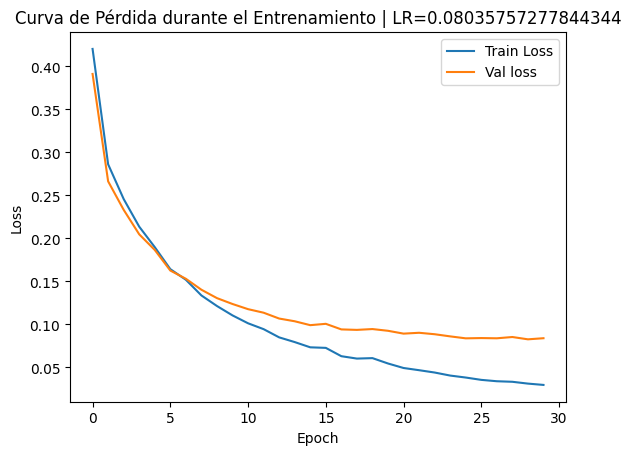

0.9759
Prueba 3: Exponente (j) = -1.4858 | Learning Rate (lr) = 0.0327
Epoch 1/30 - Train Loss: 0.6770 - Val Loss: 0.6308 - Train Acc: 0.8372 (83.72%) - Val Acc: 0.8582 (85.82%)
Epoch 2/30 - Train Loss: 0.4150 - Val Loss: 0.3778 - Train Acc: 0.8829 (88.29%) - Val Acc: 0.8946 (89.46%)
Epoch 3/30 - Train Loss: 0.3415 - Val Loss: 0.3120 - Train Acc: 0.9040 (90.40%) - Val Acc: 0.9109 (91.09%)
Epoch 4/30 - Train Loss: 0.3141 - Val Loss: 0.2900 - Train Acc: 0.9082 (90.82%) - Val Acc: 0.9158 (91.58%)
Epoch 5/30 - Train Loss: 0.2858 - Val Loss: 0.2670 - Train Acc: 0.9167 (91.67%) - Val Acc: 0.9222 (92.22%)
Epoch 6/30 - Train Loss: 0.2677 - Val Loss: 0.2511 - Train Acc: 0.9236 (92.36%) - Val Acc: 0.9257 (92.57%)
Epoch 7/30 - Train Loss: 0.2602 - Val Loss: 0.2445 - Train Acc: 0.9238 (92.38%) - Val Acc: 0.9278 (92.78%)
Epoch 8/30 - Train Loss: 0.2410 - Val Loss: 0.2291 - Train Acc: 0.9298 (92.98%) - Val Acc: 0.9339 (93.39%)
Epoch 9/30 - Train Loss: 0.2263 - Val Loss: 0.2150 - Train Acc: 0.9343 (9

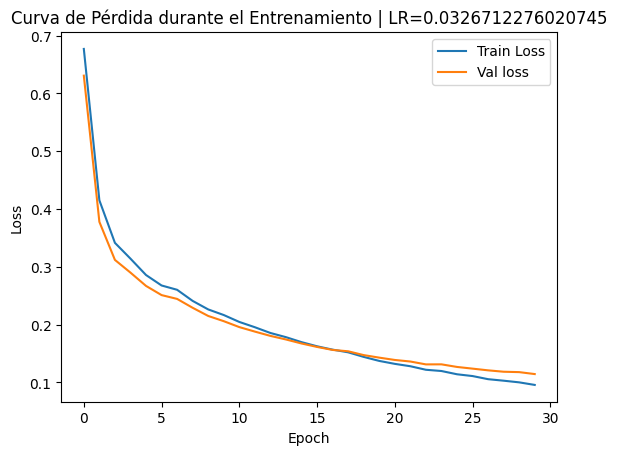

0.9666
Prueba 4: Exponente (j) = -0.2249 | Learning Rate (lr) = 0.5957
Epoch 1/30 - Train Loss: 0.1932 - Val Loss: 0.1817 - Train Acc: 0.9443 (94.43%) - Val Acc: 0.9510 (95.10%)
Epoch 2/30 - Train Loss: 0.1366 - Val Loss: 0.1475 - Train Acc: 0.9577 (95.77%) - Val Acc: 0.9559 (95.59%)
Epoch 3/30 - Train Loss: 0.1385 - Val Loss: 0.1678 - Train Acc: 0.9554 (95.54%) - Val Acc: 0.9512 (95.12%)
Epoch 4/30 - Train Loss: 0.0661 - Val Loss: 0.0991 - Train Acc: 0.9795 (97.95%) - Val Acc: 0.9689 (96.89%)
Epoch 5/30 - Train Loss: 0.0697 - Val Loss: 0.1096 - Train Acc: 0.9777 (97.77%) - Val Acc: 0.9680 (96.80%)
Epoch 6/30 - Train Loss: 0.0416 - Val Loss: 0.0846 - Train Acc: 0.9883 (98.83%) - Val Acc: 0.9748 (97.48%)
Epoch 7/30 - Train Loss: 0.0281 - Val Loss: 0.0760 - Train Acc: 0.9923 (99.23%) - Val Acc: 0.9772 (97.72%)
Epoch 8/30 - Train Loss: 0.0191 - Val Loss: 0.0739 - Train Acc: 0.9954 (99.54%) - Val Acc: 0.9798 (97.98%)
Epoch 9/30 - Train Loss: 2.0189 - Val Loss: 1.5968 - Train Acc: 0.4842 (4

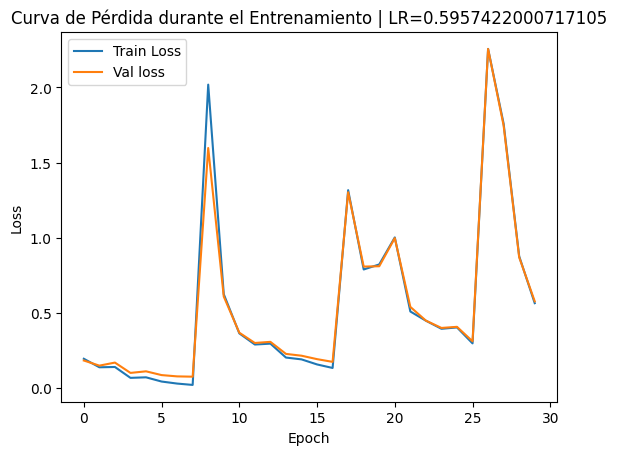

0.7949
Prueba 5: Exponente (j) = -0.2322 | Learning Rate (lr) = 0.5859
Epoch 1/30 - Train Loss: 0.3129 - Val Loss: 0.2878 - Train Acc: 0.9024 (90.24%) - Val Acc: 0.9093 (90.93%)
Epoch 2/30 - Train Loss: 0.1492 - Val Loss: 0.1481 - Train Acc: 0.9545 (95.45%) - Val Acc: 0.9567 (95.67%)
Epoch 3/30 - Train Loss: 0.1409 - Val Loss: 0.1514 - Train Acc: 0.9552 (95.52%) - Val Acc: 0.9520 (95.20%)
Epoch 4/30 - Train Loss: 0.1206 - Val Loss: 0.1417 - Train Acc: 0.9608 (96.08%) - Val Acc: 0.9575 (95.75%)
Epoch 5/30 - Train Loss: 0.0666 - Val Loss: 0.1007 - Train Acc: 0.9796 (97.96%) - Val Acc: 0.9681 (96.81%)
Epoch 6/30 - Train Loss: 0.0653 - Val Loss: 0.1060 - Train Acc: 0.9800 (98.00%) - Val Acc: 0.9685 (96.85%)
Epoch 7/30 - Train Loss: 0.0459 - Val Loss: 0.0914 - Train Acc: 0.9863 (98.63%) - Val Acc: 0.9726 (97.26%)
Epoch 8/30 - Train Loss: 0.0485 - Val Loss: 0.1057 - Train Acc: 0.9846 (98.46%) - Val Acc: 0.9695 (96.95%)
Epoch 9/30 - Train Loss: 0.0351 - Val Loss: 0.0929 - Train Acc: 0.9898 (9

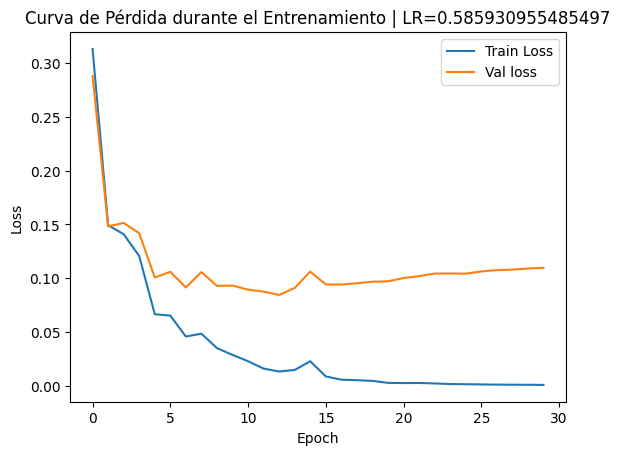

0.9783


In [94]:
import numpy as np

# Hiperparámetros
hidden1 = 200
hidden2 = 200
epochs = 30
low = 0.01
high = 1
modelos = []
for i in range(5):
    j = np.random.uniform(np.log10(low), np.log10(high))
    lr = 10**j
    print(f'Prueba {i+1}: Exponente (j) = {j:7.4f} | Learning Rate (lr) = {lr:.4f}')


    def iniciar_modelo():
        # Crear modelo
        model = nn.Sequential(
            nn.Linear(784, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)  
        )
        return model

    model = iniciar_modelo()
    # Optimizador
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    # Entrenar el modelo
    model, loss_hist_train, loss_hist_val, acc_hist_train, acc_hist_val = train_model(
        model, train_loader, val_loader, optimizer, device, epochs=epochs
    )
    plt.figure()
    plt.plot(loss_hist_train, label='Train Loss')
    plt.plot(loss_hist_val, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Curva de Pérdida durante el Entrenamiento | LR={lr}')
    plt.legend()
    plt.show()
    test_acc, test_loss = evaluate(model, test_loader, device)
    print(test_acc)
    modelos.append({'model': model, 'lr': lr, 'acc_test': test_acc})



In [99]:
import pandas as pd
df_modelos = pd.DataFrame(modelos)
df_modelos = df_modelos.sort_values(by='acc_test')
df_modelos

,model,lr,acc_test
3,"[Linear(in_features=784, out_features=200, bia...",0.595742,0.7949
2,"[Linear(in_features=784, out_features=200, bia...",0.032671,0.9666
0,"[Linear(in_features=784, out_features=200, bia...",0.046787,0.9711
1,"[Linear(in_features=784, out_features=200, bia...",0.080358,0.9759
4,"[Linear(in_features=784, out_features=200, bia...",0.585931,0.9783


### Busqueda LR en $[0.01, 0.08]$

Prueba 1: Exponente (j) = -1.3365 | Learning Rate (lr) = 0.0461
Epoch 1/30 - Train Loss: 0.4902 - Val Loss: 0.4498 - Train Acc: 0.8730 (87.30%) - Val Acc: 0.8832 (88.32%)
Epoch 2/30 - Train Loss: 0.3518 - Val Loss: 0.3222 - Train Acc: 0.8985 (89.85%) - Val Acc: 0.9112 (91.12%)
Epoch 3/30 - Train Loss: 0.3078 - Val Loss: 0.2840 - Train Acc: 0.9093 (90.93%) - Val Acc: 0.9171 (91.71%)
Epoch 4/30 - Train Loss: 0.2712 - Val Loss: 0.2543 - Train Acc: 0.9214 (92.14%) - Val Acc: 0.9257 (92.57%)
Epoch 5/30 - Train Loss: 0.2489 - Val Loss: 0.2352 - Train Acc: 0.9274 (92.74%) - Val Acc: 0.9310 (93.10%)
Epoch 6/30 - Train Loss: 0.2296 - Val Loss: 0.2186 - Train Acc: 0.9328 (93.28%) - Val Acc: 0.9366 (93.66%)
Epoch 7/30 - Train Loss: 0.2113 - Val Loss: 0.2027 - Train Acc: 0.9385 (93.85%) - Val Acc: 0.9416 (94.16%)
Epoch 8/30 - Train Loss: 0.1962 - Val Loss: 0.1904 - Train Acc: 0.9432 (94.32%) - Val Acc: 0.9470 (94.70%)
Epoch 9/30 - Train Loss: 0.1836 - Val Loss: 0.1783 - Train Acc: 0.9460 (94.60%) 

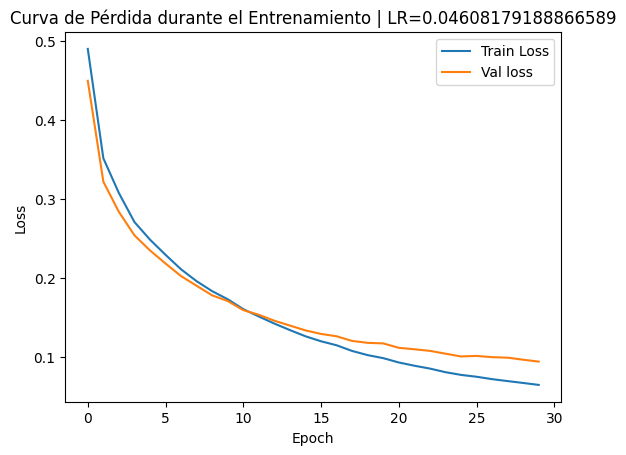

0.9725
Prueba 2: Exponente (j) = -1.9672 | Learning Rate (lr) = 0.0108
Epoch 1/30 - Train Loss: 1.8761 - Val Loss: 1.8675 - Train Acc: 0.6669 (66.69%) - Val Acc: 0.6920 (69.20%)
Epoch 2/30 - Train Loss: 1.0270 - Val Loss: 0.9968 - Train Acc: 0.7998 (79.98%) - Val Acc: 0.8222 (82.22%)
Epoch 3/30 - Train Loss: 0.6559 - Val Loss: 0.6147 - Train Acc: 0.8476 (84.76%) - Val Acc: 0.8677 (86.77%)
Epoch 4/30 - Train Loss: 0.5152 - Val Loss: 0.4740 - Train Acc: 0.8695 (86.95%) - Val Acc: 0.8864 (88.64%)
Epoch 5/30 - Train Loss: 0.4467 - Val Loss: 0.4080 - Train Acc: 0.8807 (88.07%) - Val Acc: 0.8947 (89.47%)
Epoch 6/30 - Train Loss: 0.4068 - Val Loss: 0.3711 - Train Acc: 0.8880 (88.80%) - Val Acc: 0.8992 (89.92%)
Epoch 7/30 - Train Loss: 0.3792 - Val Loss: 0.3457 - Train Acc: 0.8941 (89.41%) - Val Acc: 0.9042 (90.42%)
Epoch 8/30 - Train Loss: 0.3587 - Val Loss: 0.3281 - Train Acc: 0.8987 (89.87%) - Val Acc: 0.9097 (90.97%)
Epoch 9/30 - Train Loss: 0.3429 - Val Loss: 0.3141 - Train Acc: 0.9020 (9

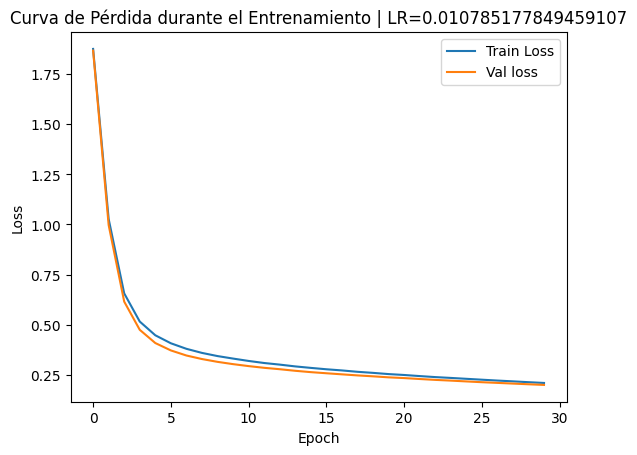

0.9397
Prueba 3: Exponente (j) = -1.2050 | Learning Rate (lr) = 0.0624
Epoch 1/30 - Train Loss: 0.4200 - Val Loss: 0.3836 - Train Acc: 0.8814 (88.14%) - Val Acc: 0.8901 (89.01%)
Epoch 2/30 - Train Loss: 0.3266 - Val Loss: 0.3018 - Train Acc: 0.9030 (90.30%) - Val Acc: 0.9134 (91.34%)
Epoch 3/30 - Train Loss: 0.2759 - Val Loss: 0.2557 - Train Acc: 0.9183 (91.83%) - Val Acc: 0.9270 (92.70%)
Epoch 4/30 - Train Loss: 0.2463 - Val Loss: 0.2330 - Train Acc: 0.9269 (92.69%) - Val Acc: 0.9321 (93.21%)
Epoch 5/30 - Train Loss: 0.2180 - Val Loss: 0.2077 - Train Acc: 0.9360 (93.60%) - Val Acc: 0.9417 (94.17%)
Epoch 6/30 - Train Loss: 0.1955 - Val Loss: 0.1889 - Train Acc: 0.9428 (94.28%) - Val Acc: 0.9472 (94.72%)
Epoch 7/30 - Train Loss: 0.1786 - Val Loss: 0.1745 - Train Acc: 0.9479 (94.79%) - Val Acc: 0.9511 (95.11%)
Epoch 8/30 - Train Loss: 0.1670 - Val Loss: 0.1664 - Train Acc: 0.9521 (95.21%) - Val Acc: 0.9553 (95.53%)
Epoch 9/30 - Train Loss: 0.1588 - Val Loss: 0.1606 - Train Acc: 0.9532 (9

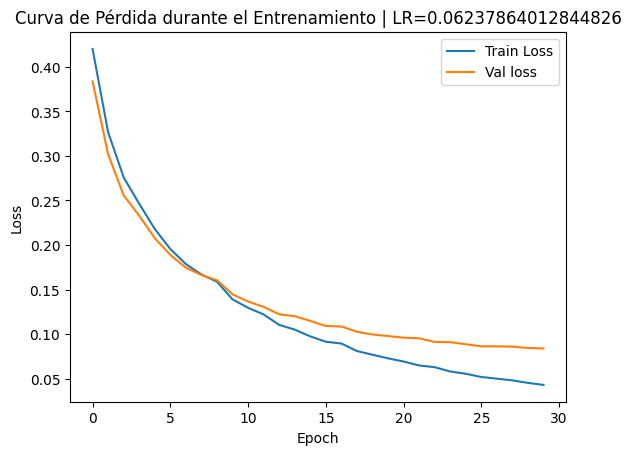

0.9775
Prueba 4: Exponente (j) = -1.7231 | Learning Rate (lr) = 0.0189
Epoch 1/30 - Train Loss: 1.0824 - Val Loss: 1.0487 - Train Acc: 0.7771 (77.71%) - Val Acc: 0.8036 (80.36%)
Epoch 2/30 - Train Loss: 0.5542 - Val Loss: 0.5084 - Train Acc: 0.8639 (86.39%) - Val Acc: 0.8805 (88.05%)
Epoch 3/30 - Train Loss: 0.4297 - Val Loss: 0.3892 - Train Acc: 0.8826 (88.26%) - Val Acc: 0.8968 (89.68%)
Epoch 4/30 - Train Loss: 0.3777 - Val Loss: 0.3422 - Train Acc: 0.8935 (89.35%) - Val Acc: 0.9060 (90.60%)
Epoch 5/30 - Train Loss: 0.3459 - Val Loss: 0.3150 - Train Acc: 0.9013 (90.13%) - Val Acc: 0.9113 (91.13%)
Epoch 6/30 - Train Loss: 0.3240 - Val Loss: 0.2960 - Train Acc: 0.9068 (90.68%) - Val Acc: 0.9164 (91.64%)
Epoch 7/30 - Train Loss: 0.3074 - Val Loss: 0.2822 - Train Acc: 0.9114 (91.14%) - Val Acc: 0.9189 (91.89%)
Epoch 8/30 - Train Loss: 0.2945 - Val Loss: 0.2720 - Train Acc: 0.9148 (91.48%) - Val Acc: 0.9214 (92.14%)
Epoch 9/30 - Train Loss: 0.2803 - Val Loss: 0.2593 - Train Acc: 0.9193 (9

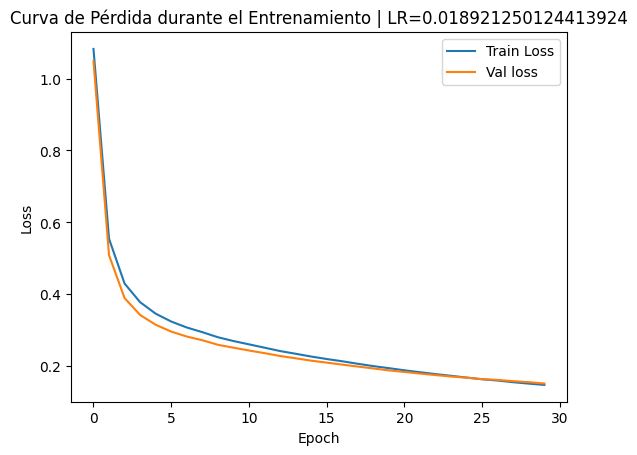

0.9539
Prueba 5: Exponente (j) = -1.4557 | Learning Rate (lr) = 0.0350
Epoch 1/30 - Train Loss: 0.6126 - Val Loss: 0.5673 - Train Acc: 0.8480 (84.80%) - Val Acc: 0.8668 (86.68%)
Epoch 2/30 - Train Loss: 0.3964 - Val Loss: 0.3606 - Train Acc: 0.8874 (88.74%) - Val Acc: 0.9007 (90.07%)
Epoch 3/30 - Train Loss: 0.3414 - Val Loss: 0.3131 - Train Acc: 0.9017 (90.17%) - Val Acc: 0.9113 (91.13%)
Epoch 4/30 - Train Loss: 0.3024 - Val Loss: 0.2799 - Train Acc: 0.9129 (91.29%) - Val Acc: 0.9204 (92.04%)
Epoch 5/30 - Train Loss: 0.2798 - Val Loss: 0.2613 - Train Acc: 0.9190 (91.90%) - Val Acc: 0.9243 (92.43%)
Epoch 6/30 - Train Loss: 0.2643 - Val Loss: 0.2480 - Train Acc: 0.9232 (92.32%) - Val Acc: 0.9277 (92.77%)
Epoch 7/30 - Train Loss: 0.2438 - Val Loss: 0.2300 - Train Acc: 0.9305 (93.05%) - Val Acc: 0.9343 (93.43%)
Epoch 8/30 - Train Loss: 0.2276 - Val Loss: 0.2152 - Train Acc: 0.9346 (93.46%) - Val Acc: 0.9404 (94.04%)
Epoch 9/30 - Train Loss: 0.2145 - Val Loss: 0.2046 - Train Acc: 0.9380 (9

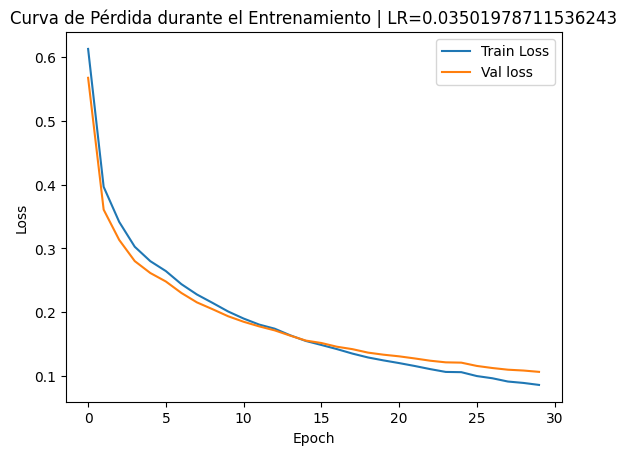

0.9686
Prueba 6: Exponente (j) = -1.5566 | Learning Rate (lr) = 0.0278
Epoch 1/30 - Train Loss: 0.7833 - Val Loss: 0.7403 - Train Acc: 0.8295 (82.95%) - Val Acc: 0.8525 (85.25%)
Epoch 2/30 - Train Loss: 0.4476 - Val Loss: 0.4070 - Train Acc: 0.8809 (88.09%) - Val Acc: 0.8940 (89.40%)
Epoch 3/30 - Train Loss: 0.3710 - Val Loss: 0.3387 - Train Acc: 0.8956 (89.56%) - Val Acc: 0.9055 (90.55%)
Epoch 4/30 - Train Loss: 0.3299 - Val Loss: 0.3023 - Train Acc: 0.9053 (90.53%) - Val Acc: 0.9138 (91.38%)
Epoch 5/30 - Train Loss: 0.3076 - Val Loss: 0.2836 - Train Acc: 0.9105 (91.05%) - Val Acc: 0.9171 (91.71%)
Epoch 6/30 - Train Loss: 0.2845 - Val Loss: 0.2633 - Train Acc: 0.9181 (91.81%) - Val Acc: 0.9233 (92.33%)
Epoch 7/30 - Train Loss: 0.2678 - Val Loss: 0.2501 - Train Acc: 0.9228 (92.28%) - Val Acc: 0.9263 (92.63%)
Epoch 8/30 - Train Loss: 0.2538 - Val Loss: 0.2379 - Train Acc: 0.9268 (92.68%) - Val Acc: 0.9295 (92.95%)
Epoch 9/30 - Train Loss: 0.2452 - Val Loss: 0.2318 - Train Acc: 0.9285 (9

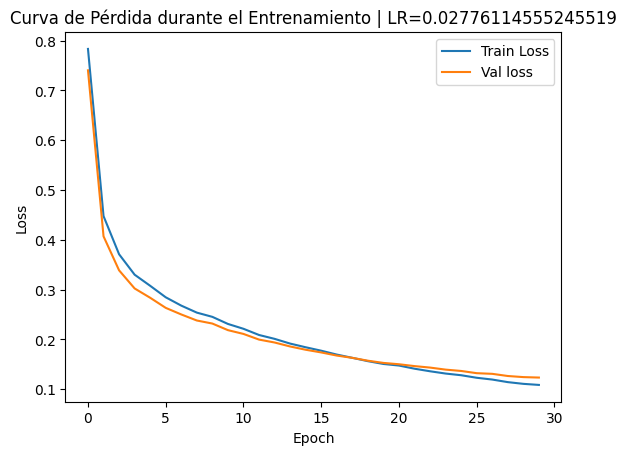

0.9644
Prueba 7: Exponente (j) = -1.4316 | Learning Rate (lr) = 0.0370
Epoch 1/30 - Train Loss: 0.5974 - Val Loss: 0.5519 - Train Acc: 0.8478 (84.78%) - Val Acc: 0.8674 (86.74%)
Epoch 2/30 - Train Loss: 0.3836 - Val Loss: 0.3491 - Train Acc: 0.8936 (89.36%) - Val Acc: 0.9025 (90.25%)
Epoch 3/30 - Train Loss: 0.3255 - Val Loss: 0.2989 - Train Acc: 0.9065 (90.65%) - Val Acc: 0.9120 (91.20%)
Epoch 4/30 - Train Loss: 0.2944 - Val Loss: 0.2727 - Train Acc: 0.9147 (91.47%) - Val Acc: 0.9220 (92.20%)
Epoch 5/30 - Train Loss: 0.2703 - Val Loss: 0.2519 - Train Acc: 0.9199 (91.99%) - Val Acc: 0.9255 (92.55%)
Epoch 6/30 - Train Loss: 0.2484 - Val Loss: 0.2337 - Train Acc: 0.9279 (92.79%) - Val Acc: 0.9311 (93.11%)
Epoch 7/30 - Train Loss: 0.2318 - Val Loss: 0.2187 - Train Acc: 0.9333 (93.33%) - Val Acc: 0.9358 (93.58%)
Epoch 8/30 - Train Loss: 0.2173 - Val Loss: 0.2072 - Train Acc: 0.9373 (93.73%) - Val Acc: 0.9398 (93.98%)
Epoch 9/30 - Train Loss: 0.2052 - Val Loss: 0.1972 - Train Acc: 0.9410 (9

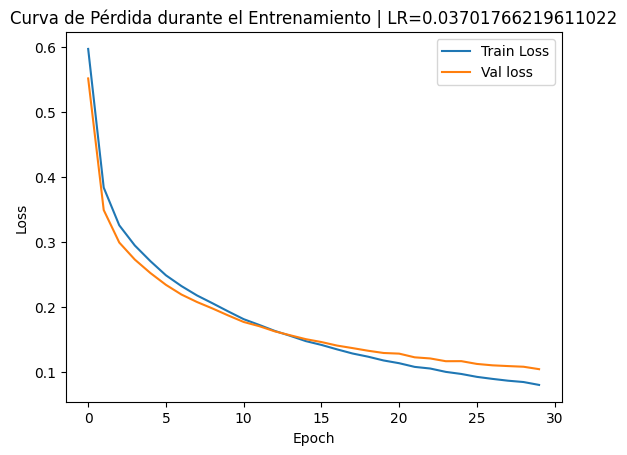

0.9698
Prueba 8: Exponente (j) = -1.1590 | Learning Rate (lr) = 0.0694
Epoch 1/30 - Train Loss: 0.4310 - Val Loss: 0.3916 - Train Acc: 0.8760 (87.60%) - Val Acc: 0.8851 (88.51%)
Epoch 2/30 - Train Loss: 0.3120 - Val Loss: 0.2854 - Train Acc: 0.9077 (90.77%) - Val Acc: 0.9159 (91.59%)
Epoch 3/30 - Train Loss: 0.2648 - Val Loss: 0.2494 - Train Acc: 0.9227 (92.27%) - Val Acc: 0.9272 (92.72%)
Epoch 4/30 - Train Loss: 0.2324 - Val Loss: 0.2205 - Train Acc: 0.9311 (93.11%) - Val Acc: 0.9357 (93.57%)
Epoch 5/30 - Train Loss: 0.2064 - Val Loss: 0.1991 - Train Acc: 0.9406 (94.06%) - Val Acc: 0.9436 (94.36%)
Epoch 6/30 - Train Loss: 0.1920 - Val Loss: 0.1853 - Train Acc: 0.9443 (94.43%) - Val Acc: 0.9482 (94.82%)
Epoch 7/30 - Train Loss: 0.1690 - Val Loss: 0.1659 - Train Acc: 0.9505 (95.05%) - Val Acc: 0.9528 (95.28%)
Epoch 8/30 - Train Loss: 0.1531 - Val Loss: 0.1544 - Train Acc: 0.9557 (95.57%) - Val Acc: 0.9570 (95.70%)
Epoch 9/30 - Train Loss: 0.1410 - Val Loss: 0.1452 - Train Acc: 0.9588 (9

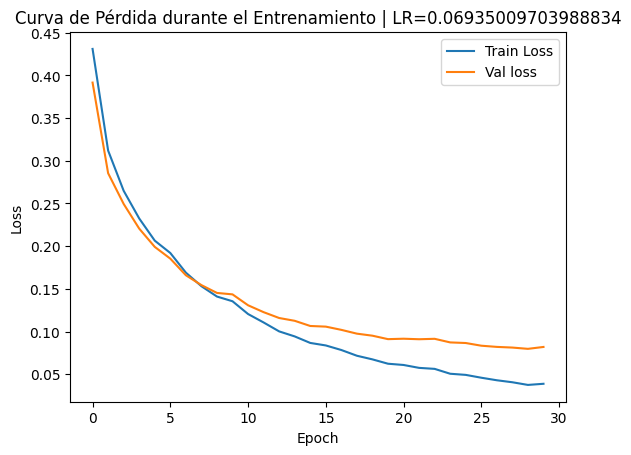

0.976
Prueba 9: Exponente (j) = -1.7905 | Learning Rate (lr) = 0.0162
Epoch 1/30 - Train Loss: 1.3797 - Val Loss: 1.3586 - Train Acc: 0.7327 (73.27%) - Val Acc: 0.7558 (75.58%)
Epoch 2/30 - Train Loss: 0.6370 - Val Loss: 0.5942 - Train Acc: 0.8477 (84.77%) - Val Acc: 0.8682 (86.82%)
Epoch 3/30 - Train Loss: 0.4689 - Val Loss: 0.4287 - Train Acc: 0.8758 (87.58%) - Val Acc: 0.8915 (89.15%)
Epoch 4/30 - Train Loss: 0.4012 - Val Loss: 0.3652 - Train Acc: 0.8889 (88.89%) - Val Acc: 0.8994 (89.94%)
Epoch 5/30 - Train Loss: 0.3632 - Val Loss: 0.3314 - Train Acc: 0.8969 (89.69%) - Val Acc: 0.9083 (90.83%)
Epoch 6/30 - Train Loss: 0.3390 - Val Loss: 0.3096 - Train Acc: 0.9029 (90.29%) - Val Acc: 0.9121 (91.21%)
Epoch 7/30 - Train Loss: 0.3219 - Val Loss: 0.2962 - Train Acc: 0.9071 (90.71%) - Val Acc: 0.9137 (91.37%)
Epoch 8/30 - Train Loss: 0.3070 - Val Loss: 0.2825 - Train Acc: 0.9118 (91.18%) - Val Acc: 0.9187 (91.87%)
Epoch 9/30 - Train Loss: 0.2931 - Val Loss: 0.2714 - Train Acc: 0.9150 (91

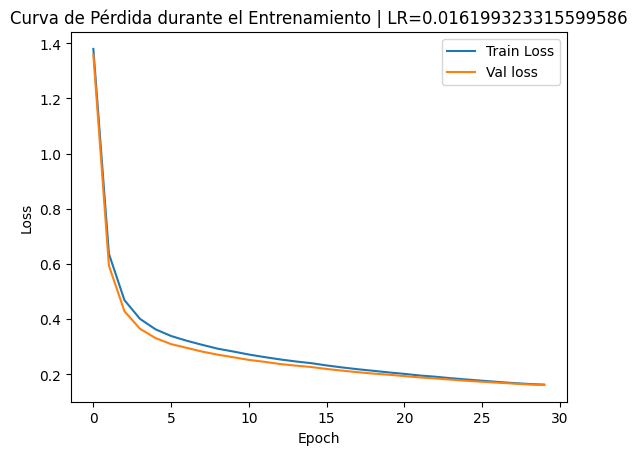

0.9508
Prueba 10: Exponente (j) = -1.5092 | Learning Rate (lr) = 0.0310
Epoch 1/30 - Train Loss: 0.7149 - Val Loss: 0.6740 - Train Acc: 0.8422 (84.22%) - Val Acc: 0.8609 (86.09%)
Epoch 2/30 - Train Loss: 0.4186 - Val Loss: 0.3823 - Train Acc: 0.8851 (88.51%) - Val Acc: 0.8954 (89.54%)
Epoch 3/30 - Train Loss: 0.3489 - Val Loss: 0.3192 - Train Acc: 0.9013 (90.13%) - Val Acc: 0.9078 (90.78%)
Epoch 4/30 - Train Loss: 0.3159 - Val Loss: 0.2913 - Train Acc: 0.9081 (90.81%) - Val Acc: 0.9148 (91.48%)
Epoch 5/30 - Train Loss: 0.2901 - Val Loss: 0.2691 - Train Acc: 0.9166 (91.66%) - Val Acc: 0.9209 (92.09%)
Epoch 6/30 - Train Loss: 0.2706 - Val Loss: 0.2522 - Train Acc: 0.9216 (92.16%) - Val Acc: 0.9262 (92.62%)
Epoch 7/30 - Train Loss: 0.2552 - Val Loss: 0.2384 - Train Acc: 0.9257 (92.57%) - Val Acc: 0.9306 (93.06%)
Epoch 8/30 - Train Loss: 0.2427 - Val Loss: 0.2299 - Train Acc: 0.9300 (93.00%) - Val Acc: 0.9330 (93.30%)
Epoch 9/30 - Train Loss: 0.2291 - Val Loss: 0.2167 - Train Acc: 0.9333 (

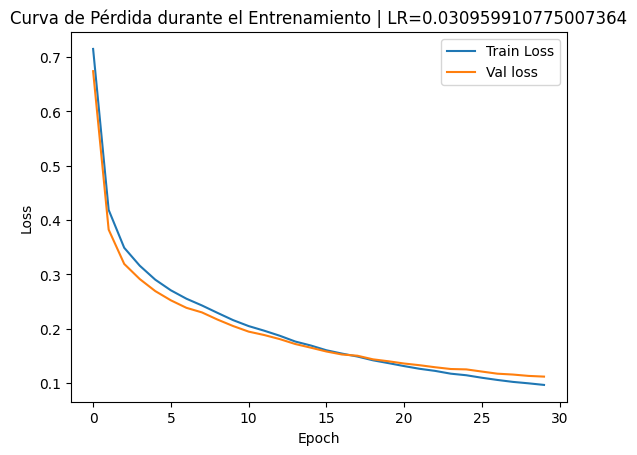

0.9669


In [38]:
import numpy as np

# Hiperparámetros
hidden1 = 200
hidden2 = 200
epochs = 30
low = 0.01
high = 0.08
modelos = []
for i in range(10):
    j = np.random.uniform(np.log10(low), np.log10(high))
    lr = 10**j
    print(f'Prueba {i+1}: Exponente (j) = {j:7.4f} | Learning Rate (lr) = {lr:.4f}')


    def iniciar_modelo():
        # Crear modelo
        model = nn.Sequential(
            nn.Linear(784, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)  
        )
        return model

    model = iniciar_modelo()
    # Optimizador
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    # Entrenar el modelo
    model, loss_hist_train, loss_hist_val, acc_hist_train, acc_hist_val = train_model(
        model, train_loader, val_loader, optimizer, device, epochs=epochs
    )
    plt.figure()
    plt.plot(loss_hist_train, label='Train Loss')
    plt.plot(loss_hist_val, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Curva de Pérdida durante el Entrenamiento | LR={lr}')
    plt.legend()
    plt.show()
    test_acc, test_loss = evaluate(model, test_loader, device)
    print(test_acc)
    modelos.append({'model': model, 'lr': lr, 'acc_test': test_acc})



In [44]:
import pandas as pd
df_modelos = pd.DataFrame(modelos)
df_modelos = df_modelos.sort_values(by='acc_test', ascending=False)
df_modelos

,model,lr,acc_test
2,"[Linear(in_features=784, out_features=200, bia...",0.062379,0.9775
7,"[Linear(in_features=784, out_features=200, bia...",0.069350,0.9760
0,"[Linear(in_features=784, out_features=200, bia...",0.046082,0.9725
6,"[Linear(in_features=784, out_features=200, bia...",0.037018,0.9698
4,"[Linear(in_features=784, out_features=200, bia...",0.035020,0.9686
9,"[Linear(in_features=784, out_features=200, bia...",0.030960,0.9669
5,"[Linear(in_features=784, out_features=200, bia...",0.027761,0.9644
3,"[Linear(in_features=784, out_features=200, bia...",0.018921,0.9539
8,"[Linear(in_features=784, out_features=200, bia...",0.016199,0.9508
1,"[Linear(in_features=784, out_features=200, bia...",0.010785,0.9397


In [45]:
model = df_modelos.iloc[0]['model']

## Guardar Modelo

In [46]:
model_path = '../models/modelMNIST_hyper.pth'

In [47]:
torch.save(
    model.state_dict(),
    model_path
)

### Opción 2

In [48]:
model_completo_path = '../models/modelMNIST_completo_hyper.pth'

In [49]:
torch.save(model, model_completo_path)